<a href="https://colab.research.google.com/github/leticiasouza74-cpu/FundamentosComputacionais/blob/main/CSTR_s%C3%A9rie_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

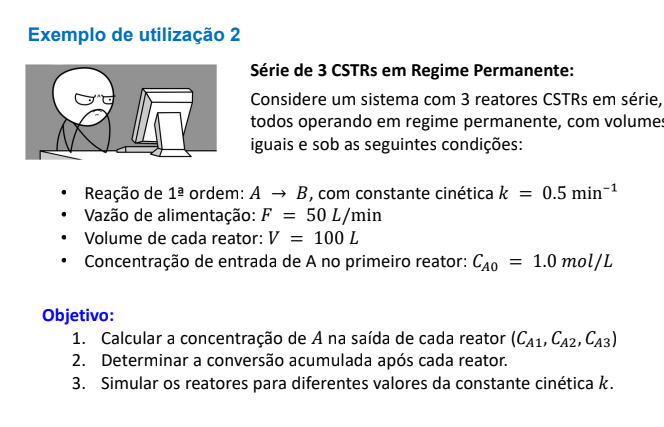

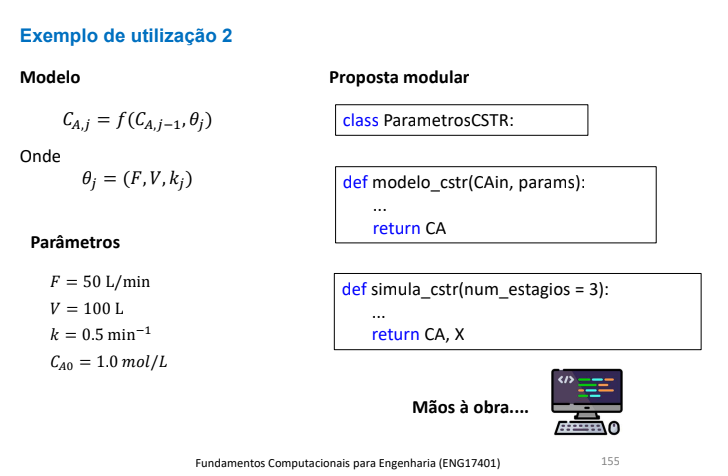

In [32]:
from dataclasses import dataclass
import numpy as np
from scipy.integrate import solve_ivp


@dataclass
class ParametrosCSTR:
  """
  Atributos:
  F = vazão de alimentação em L/min
  V = volume de cada reator em L
  Ca0 = Concentração de entrada de A no primeiro reator em mol/L
  k = constante cinética em min^-1
  """

  F: float = 50
  V: float = 100
  k: float = 0.5


In [33]:
def cstr(Cai, paran):
  F = paran.F
  V = paran.V
  k = paran.k

  Ca = (F/(F + V*k))*Cai
  return Ca

In [35]:
def simula(Ca0 = 1, n = 3, paran = None):
  if paran is None:
    paran = [ParametrosCSTR() for _ in range(3)]

  Cai = Ca0

  Ca = np.zeros(n)
  X = np.zeros(n)

  for j in range(n):

    Ca[j] = cstr(Cai, paran[j])

    X[j] = (Ca0 - Ca[j]) / Ca0

    Cai = Ca[j]

  return Ca, X